<a href="https://colab.research.google.com/github/nurallyssaroslan/KD344403-S2-25-26-G8-PROJECT/blob/main/MLDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
raw_dataset = "ai_vs_human_content_v2_20000.csv"
df = pd.read_csv(raw_dataset)
display(df.head(10))

,id,prompt,content,type,source,label,topic,word_count,char_count,ai_model,language,complexity_score,is_multiline_code
0,1,Write a string manipulation solution in python,def string_manipulation():\n # TODO: implem...,code,blog,human,string manipulation,9,84,NaN,python,3,True
1,2,Explain health in simple terms,Experts recommend focusing on health to improv...,text,generated,ai,health,29,211,Claude,en,3,False
2,3,Summarize recent developments in finance,The development of finance technologies has ac...,text,generated,ai,finance,56,419,GPT-4,en,5,False
3,4,Summarize recent developments in finance,Recent studies show that finance can have sign...,text,generated,ai,finance,42,298,Claude,en,10,False
4,5,Provide a graph traversal algorithm in cpp,vector<int> arr; // graph traversal example\nf...,code,generated,ai,graph traversal,11,98,Gemini,cpp,10,True
5,6,Write a story about politics,politics has become increasingly important in ...,text,news,human,politics,48,354,NaN,en,9,False
6,7,Write a graph traversal solution in python,arr = [i for i in range(10)] # graph traversal...,code,news,human,graph traversal,11,54,NaN,python,8,False
7,8,Write a story about tech,Recent studies show that tech can have signifi...,text,news,human,tech,53,352,NaN,en,5,False
8,9,Summarize recent developments in politics,Experts recommend focusing on politics to impr...,text,generated,ai,politics,50,370,Gemini,en,8,False
9,10,Provide a graph traversal algorithm in java,public class graph_traversal {\n public sta...,code,generated,ai,graph traversal,18,135,Claude,java,10,True


In [ ]:
print(df['language'].unique())

['python' 'en' 'cpp' 'java']


In [ ]:
print(df['language'].value_counts())

language
en        10004
java       3409
cpp        3329
python     3258
Name: count, dtype: int64


In [ ]:
df_en = df[df['language'] == 'en']
display(df_en.head())

,id,prompt,content,type,source,label,topic,word_count,char_count,ai_model,language,complexity_score,is_multiline_code
1,2,Explain health in simple terms,Experts recommend focusing on health to improv...,text,generated,ai,health,29,211,Claude,en,3,False
2,3,Summarize recent developments in finance,The development of finance technologies has ac...,text,generated,ai,finance,56,419,GPT-4,en,5,False
3,4,Summarize recent developments in finance,Recent studies show that finance can have sign...,text,generated,ai,finance,42,298,Claude,en,10,False
5,6,Write a story about politics,politics has become increasingly important in ...,text,news,human,politics,48,354,NaN,en,9,False
7,8,Write a story about tech,Recent studies show that tech can have signifi...,text,news,human,tech,53,352,NaN,en,5,False


In [ ]:
print(df_en['is_multiline_code'].unique())

[False]


In [ ]:
df_en = df_en.drop(columns=['is_multiline_code'], errors='ignore')
display(df_en.head())

# dropped due to irrelevance

,id,prompt,content,source,label,topic,word_count,char_count,ai_model,complexity_score
1,2,Explain health in simple terms,Experts recommend focusing on health to improv...,generated,ai,health,29,211,Claude,3
2,3,Summarize recent developments in finance,The development of finance technologies has ac...,generated,ai,finance,56,419,GPT-4,5
3,4,Summarize recent developments in finance,Recent studies show that finance can have sign...,generated,ai,finance,42,298,Claude,10
5,6,Write a story about politics,politics has become increasingly important in ...,news,human,politics,48,354,NaN,9
7,8,Write a story about tech,Recent studies show that tech can have signifi...,news,human,tech,53,352,NaN,5


In [ ]:
print(df_en.isnull().sum())

id                     0
prompt                 0
content                0
source                 0
label                  0
topic                  0
word_count             0
char_count             0
ai_model            4937
complexity_score       0
dtype: int64


In [ ]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 5.2 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df_en, title="English DataFrame Profiling Report")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:01<00:00,  9.82it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
df_source_github = df_en[df_en['source'].str.contains('github', case=False, na=False)]
display(df_source_github)

,id,prompt,content,type,source,label,topic,word_count,char_count,ai_model,language,complexity_score
44,45,Explain health in simple terms,Recent studies show that health can have signi...,text,github,human,health,52,356,NaN,en,8
58,59,Write a blog post discussing health,The development of health technologies has acc...,text,github,human,health,50,345,NaN,en,1
71,72,Summarize recent developments in sports,sports has become increasingly important in to...,text,github,human,sports,50,344,NaN,en,3
74,75,Write a story about finance,Experts recommend focusing on finance to impro...,text,github,human,finance,45,330,NaN,en,7
78,79,Summarize recent developments in politics,Recent studies show that politics can have sig...,text,github,human,politics,29,209,NaN,en,1
...,...,...,...,...,...,...,...,...,...,...,...,...
19887,19888,Explain politics in simple terms,politics has become increasingly important in ...,text,github,human,politics,53,396,NaN,en,4
19901,19902,Write a news article about sports,Understanding sports is crucial for profession...,text,github,human,sports,27,195,NaN,en,8
19909,19910,Write a story about health,Understanding health is crucial for profession...,text,github,human,health,53,384,NaN,en,1
19923,19924,Explain sports in simple terms,sports has become increasingly important in to...,text,github,human,sports,28,201,NaN,en,4


In [ ]:
df_en = df_en.drop(columns=['type'], errors='ignore')
display(df_en.head())

# dropped due to it being constant thus not contributing to the prediction

,id,prompt,content,source,label,topic,word_count,char_count,ai_model,complexity_score
1,2,Explain health in simple terms,Experts recommend focusing on health to improv...,generated,ai,health,29,211,Claude,3
2,3,Summarize recent developments in finance,The development of finance technologies has ac...,generated,ai,finance,56,419,GPT-4,5
3,4,Summarize recent developments in finance,Recent studies show that finance can have sign...,generated,ai,finance,42,298,Claude,10
5,6,Write a story about politics,politics has become increasingly important in ...,news,human,politics,48,354,NaN,9
7,8,Write a story about tech,Recent studies show that tech can have signifi...,news,human,tech,53,352,NaN,5


In [ ]:
df_en = df_en.drop(columns=['language'], errors='ignore')
display(df_en.head())

# dropped due to it being constant thus not contributing to the prediction

,id,prompt,content,source,label,topic,word_count,char_count,ai_model,complexity_score
1,2,Explain health in simple terms,Experts recommend focusing on health to improv...,generated,ai,health,29,211,Claude,3
2,3,Summarize recent developments in finance,The development of finance technologies has ac...,generated,ai,finance,56,419,GPT-4,5
3,4,Summarize recent developments in finance,Recent studies show that finance can have sign...,generated,ai,finance,42,298,Claude,10
5,6,Write a story about politics,politics has become increasingly important in ...,news,human,politics,48,354,NaN,9
7,8,Write a story about tech,Recent studies show that tech can have signifi...,news,human,tech,53,352,NaN,5


In [ ]:
df_en = df_en.drop(columns=['prompt'])
display(df_en.head())

# dropped to prevent bias as prompt can be engineered to specifically cater to ai

,id,content,source,label,topic,word_count,char_count,ai_model,complexity_score
1,2,Experts recommend focusing on health to improv...,generated,ai,health,29,211,Claude,3
2,3,The development of finance technologies has ac...,generated,ai,finance,56,419,GPT-4,5
3,4,Recent studies show that finance can have sign...,generated,ai,finance,42,298,Claude,10
5,6,politics has become increasingly important in ...,news,human,politics,48,354,NaN,9
7,8,Recent studies show that tech can have signifi...,news,human,tech,53,352,NaN,5


In [ ]:
df_en = df_en.drop(columns=['topic'])
display(df_en.head())

# dropped due to irrelevance

,id,content,source,label,word_count,char_count,ai_model,complexity_score
1,2,Experts recommend focusing on health to improv...,generated,ai,29,211,Claude,3
2,3,The development of finance technologies has ac...,generated,ai,56,419,GPT-4,5
3,4,Recent studies show that finance can have sign...,generated,ai,42,298,Claude,10
5,6,politics has become increasingly important in ...,news,human,48,354,NaN,9
7,8,Recent studies show that tech can have signifi...,news,human,53,352,NaN,5


In [ ]:
df_en = df_en.drop(columns=['id'])
display(df_en.head())

# dropped as there is no predictive value

,content,source,label,word_count,char_count,ai_model,complexity_score
1,Experts recommend focusing on health to improv...,generated,ai,29,211,Claude,3
2,The development of finance technologies has ac...,generated,ai,56,419,GPT-4,5
3,Recent studies show that finance can have sign...,generated,ai,42,298,Claude,10
5,politics has become increasingly important in ...,news,human,48,354,NaN,9
7,Recent studies show that tech can have signifi...,news,human,53,352,NaN,5


In [ ]:
df_en['content'] = df_en['content'].str.lower()
display(df_en.head())

,content,source,label,word_count,char_count,ai_model,complexity_score
1,experts recommend focusing on health to improv...,generated,ai,29,211,Claude,3
2,the development of finance technologies has ac...,generated,ai,56,419,GPT-4,5
3,recent studies show that finance can have sign...,generated,ai,42,298,Claude,10
5,politics has become increasingly important in ...,news,human,48,354,NaN,9
7,recent studies show that tech can have signifi...,news,human,53,352,NaN,5


In [ ]:
df_en['ai_model'] = df_en['ai_model'].str.lower()
display(df_en.head())

,content,source,label,word_count,char_count,ai_model,complexity_score
1,experts recommend focusing on health to improv...,generated,ai,29,211,claude,3
2,the development of finance technologies has ac...,generated,ai,56,419,gpt-4,5
3,recent studies show that finance can have sign...,generated,ai,42,298,claude,10
5,politics has become increasingly important in ...,news,human,48,354,NaN,9
7,recent studies show that tech can have signifi...,news,human,53,352,NaN,5


/tmp/ipykernel_32068/1941919298.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_en, palette='viridis')


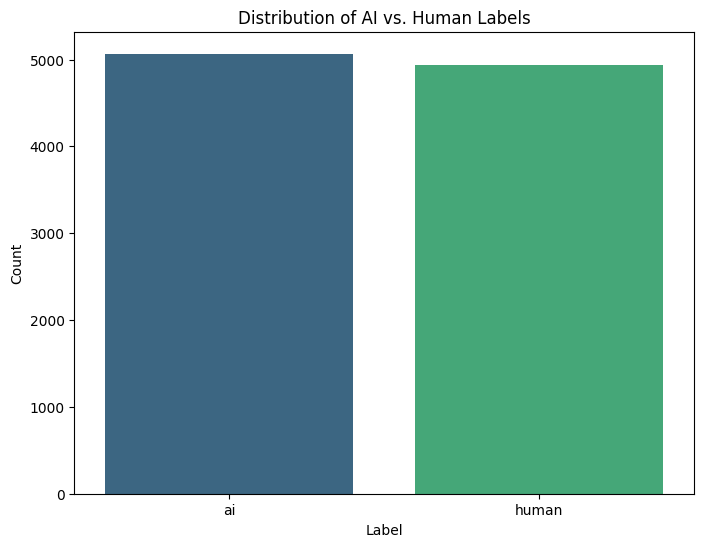

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df_en, palette='viridis')
plt.title('Distribution of AI vs. Human Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [ ]:
print(df_en['label'].value_counts())

label
ai       5067
human    4937
Name: count, dtype: int64


In [ ]:
print('Summary Statistics:')
display(df_en.describe())

Summary Statistics:


,word_count,char_count,complexity_score
count,10004.000000,10004.000000,10004.000000
mean,43.593263,314.177829,5.507797
std,11.022402,78.408091,2.877734
min,24.000000,176.000000,1.000000
25%,34.000000,240.000000,3.000000
50%,43.000000,314.000000,6.000000
75%,53.000000,381.000000,8.000000
max,67.000000,473.000000,10.000000


In [ ]:
df_en.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10004 entries, 1 to 19992
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   content           10004 non-null  object
 1   source            10004 non-null  object
 2   label             10004 non-null  object
 3   word_count        10004 non-null  int64 
 4   char_count        10004 non-null  int64 
 5   ai_model          5067 non-null   object
 6   complexity_score  10004 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 883.3+ KB


/tmp/ipykernel_32068/151890388.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='ai_model', data=df_en, palette='cubehelix', order=df_en['ai_model'].value_counts().index)


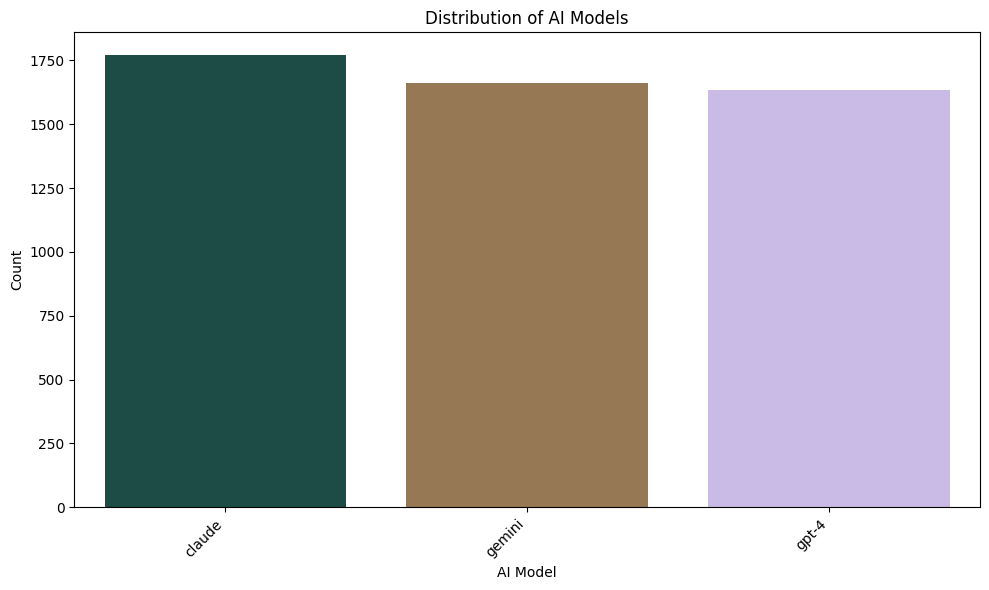

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='ai_model', data=df_en, palette='cubehelix', order=df_en['ai_model'].value_counts().index)
plt.title('Distribution of AI Models')
plt.xlabel('AI Model')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
print(df_en['ai_model'].value_counts())

ai_model
claude    1771
gemini    1661
gpt-4     1635
Name: count, dtype: int64
